In [8]:
import sys
sys.path.append('../models/numpy_models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from neuralnet import NeuralNetwork
from layers import DenseLayer, DropoutLayer
from activation import ReLUActivation, SoftmaxActivation
from losses import CategoricalCrossEntropy
from metrics import accuracy

In [9]:
# 1. Carregar os dados limpos
df = pd.read_csv('../data/dataset_limpo.csv', sep=';')
df = df.dropna(subset=['Text', 'Label'])

X = df['Text']
y = df['Label']

# 2. Converter as Labels (Texto) para One-Hot Encoding (Obrigatório para Softmax!)
y_encoded = pd.get_dummies(y).astype(int).values
classes = pd.get_dummies(y).columns
print(f"Classes detetadas: {list(classes)}")

# 3. Divisão em Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# 4. TF-IDF (Transformar palavras em números)
# max_features=2000 para não sobrecarregar a implementação própria (Numpy puro)
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')

# Importante: A nossa rede precisa de Arrays Densos (.toarray()) e não matrizes esparsas
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

print(f"Formato de Entrada do Treino: {X_train_tfidf.shape}")

Classes detetadas: ['Google', 'Human', 'Meta', 'Mistral', 'OpenAI']
Formato de Entrada do Treino: (3944, 2000)


In [10]:
class TextDataset:
    def __init__(self, X, y):
        self.X = X
        self.y = y

train_dataset = TextDataset(X_train_tfidf, y_train)
test_dataset = TextDataset(X_test_tfidf, y_test)

In [11]:
print("--- A Treinar Baseline: Regressão Logística ---")
baseline_model = NeuralNetwork(epochs=60, batch_size=64, learning_rate=0.05, verbose=True, loss=CategoricalCrossEntropy, metric=accuracy)

n_features = X_train_tfidf.shape[1]

# Ligar a entrada diretamente à saída (5 classes), sem camadas ocultas!
baseline_model.add(DenseLayer(5, input_shape=(n_features,)))
baseline_model.add(SoftmaxActivation())

baseline_model.fit(train_dataset)

# Avaliar a Baseline
y_pred_base = baseline_model.predict(test_dataset)
acc_base = baseline_model.score(test_dataset, y_pred_base)
print(f"\nAccuracy da Baseline (Teste): {acc_base*100:.2f}%\n")

--- A Treinar Baseline: Regressão Logística ---
Epoch 1/60 - loss: 1.6204 - accuracy: 0.3015
Epoch 10/60 - loss: 1.4862 - accuracy: 0.3854
Epoch 20/60 - loss: 1.4300 - accuracy: 0.4455
Epoch 30/60 - loss: 1.3784 - accuracy: 0.4926
Epoch 40/60 - loss: 1.3331 - accuracy: 0.5198
Epoch 50/60 - loss: 1.2901 - accuracy: 0.5474
Epoch 60/60 - loss: 1.2517 - accuracy: 0.5710

Accuracy da Baseline (Teste): 54.51%



In [12]:
net = NeuralNetwork(epochs=200, batch_size=64, learning_rate=0.05, verbose=True,
                    loss=CategoricalCrossEntropy, metric=accuracy)

n_features = X_train_tfidf.shape[1]

# Camada Oculta: 64 Neurónios com ativação ReLU
net.add(DenseLayer(64, input_shape=(n_features,)))
net.add(ReLUActivation())

net.add(DropoutLayer(0.2)) # protecao contra overfitting

# Camada de Saída: 5 Neurónios (porque temos 5 classes) com ativação Softmax
net.add(DenseLayer(5))
net.add(SoftmaxActivation())

print("A iniciar o treino da rede...")
net.fit(train_dataset)

A iniciar o treino da rede...
Epoch 1/200 - loss: 1.6174 - accuracy: 0.3294
Epoch 10/200 - loss: 1.4405 - accuracy: 0.4544
Epoch 20/200 - loss: 1.3352 - accuracy: 0.5236
Epoch 30/200 - loss: 1.2104 - accuracy: 0.5768
Epoch 40/200 - loss: 1.1023 - accuracy: 0.6268
Epoch 50/200 - loss: 1.0033 - accuracy: 0.6699
Epoch 60/200 - loss: 0.9268 - accuracy: 0.7072
Epoch 70/200 - loss: 0.8631 - accuracy: 0.7426
Epoch 80/200 - loss: 0.7872 - accuracy: 0.7710
Epoch 90/200 - loss: 0.7310 - accuracy: 0.7956
Epoch 100/200 - loss: 0.6725 - accuracy: 0.8126
Epoch 110/200 - loss: 0.6258 - accuracy: 0.8357
Epoch 120/200 - loss: 0.5758 - accuracy: 0.8507
Epoch 130/200 - loss: 0.5341 - accuracy: 0.8692
Epoch 140/200 - loss: 0.4918 - accuracy: 0.8826
Epoch 150/200 - loss: 0.4638 - accuracy: 0.8933
Epoch 160/200 - loss: 0.4396 - accuracy: 0.9082
Epoch 170/200 - loss: 0.4077 - accuracy: 0.9186
Epoch 180/200 - loss: 0.3767 - accuracy: 0.9303
Epoch 190/200 - loss: 0.3603 - accuracy: 0.9394
Epoch 200/200 - loss:


Accuracy no Teste: 82.78%


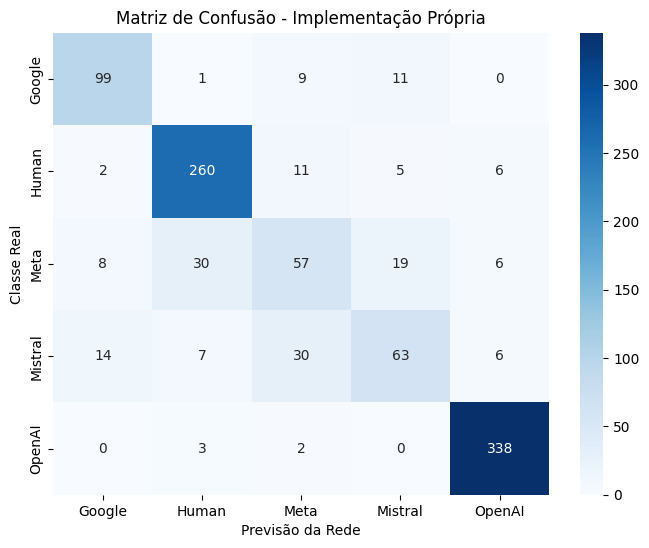

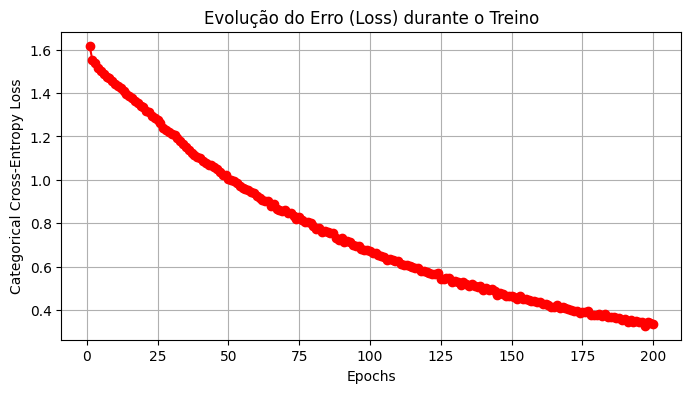

In [13]:
# Fazer previsões no Teste
y_pred_prob = net.predict(test_dataset)

# Calcular a Accuracy
acc = net.score(test_dataset, y_pred_prob)
print(f"\nAccuracy no Teste: {acc*100:.2f}%")

# Converter probabilidades de volta para nomes das classes para a Matriz de Confusão
y_pred_classes = [classes[np.argmax(p)] for p in y_pred_prob]
y_true_classes = [classes[np.argmax(t)] for t in y_test]

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - Implementação Própria')
plt.ylabel('Classe Real')
plt.xlabel('Previsão da Rede')
plt.show()

# Gráfico do Loss ao longo das Epochs
epochs = list(net.history.keys())
losses = [net.history[e]['loss'] for e in epochs]

plt.figure(figsize=(8, 4))
plt.plot(epochs, losses, marker='o', color='red')
plt.title('Evolução do Erro (Loss) durante o Treino')
plt.xlabel('Epochs')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.grid()
plt.show()